# Module 3 — Digital Twin Fusion
### Agent-Based Digital Twin | Frozen Fruit Quality

---
**What this module does:**
Fuses CNN visual features (Module 1) with BiLSTM temporal features (Module 2)
into a single 1536-dim Digital Twin state vector, then trains a fusion head
to predict the final quality score q̂.

```
Module 1 → CNN embedding       (N, 1280)  visual degradation
Module 2 → BiLSTM embedding    (N,  256)  temporal sensor
                ↓ concatenate
         Digital Twin state    (N, 1536)
                ↓ fusion head
         Quality score q̂       (N,    1)  → Module 4 agent
```

**How embeddings are obtained:**
- Module 1 embeddings: extracted from `gap` layer of EfficientNetB0
- Module 2 embeddings: extracted from `embedding` Dense(256) layer of BiLSTM
- Both saved as `.npy` files during their respective module runs
- If not available on Drive, this notebook regenerates them

**Target:** RMSE < 0.0954

---
**Before running:** Runtime → Change runtime type → T4 GPU

---
## CELL 1 — Install & Import

In [1]:
# ================================================================
# CELL 1: Install & Import
# ================================================================
!pip install -q opencv-python-headless scikit-learn tqdm

import os, math, random, warnings, pickle, shutil, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Exactly matching Module 1 and Module 2 constants
CLASS_NAMES  = ['Fresh', 'Slightly Degraded', 'Spoiled']
CLASS_COLORS = ['#2ecc71', '#f39c12', '#e74c3c']
FRUIT_LIST   = ['apple', 'banana', 'orange']
FRUIT_COLORS = ['#c0392b', '#f1c40f', '#e67e22']
IMG_SIZE     = 224
BATCH_SIZE   = 32
TIMESTEPS    = 30
N_FEATURES   = 4
R_GAS        = 8.314

OUT_DIR = Path('/content/module3_outputs')
OUT_DIR.mkdir(exist_ok=True)

print('=' * 50)
print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {len(tf.config.list_physical_devices("GPU")) > 0}')
print('All imports OK!')
print('=' * 50)

TensorFlow : 2.20.0
GPU        : False
All imports OK!


---
## CELL 2 — Mount Google Drive

In [2]:
# ================================================================
# CELL 2: Mount Google Drive
# ================================================================
from google.colab import drive
drive.mount('/gdrive')

# Paths — update if your filenames differ
M1_MODEL_PATH = '/gdrive/MyDrive/FrozenFruitModule1/best_phase2.keras'
M2_MODEL_PATH = '/gdrive/MyDrive/FrozenFruitModule2/bilstm_frozen_fruit.keras'
M1_EMB_DIR    = Path('/gdrive/MyDrive/FrozenFruitModule1/embeddings_module1')
M2_EMB_DIR    = Path('/gdrive/MyDrive/FrozenFruitModule2/embeddings_module2')
ZIP_SOURCE    = '/gdrive/MyDrive/fruits-fresh-and-rotten-for-classification.zip'

DRIVE_DIR = Path('/gdrive/MyDrive/FrozenFruitModule3')
DRIVE_DIR.mkdir(parents=True, exist_ok=True)

print('Checking what is available in Drive...')
print()

# Check Module 1 folder
m1_folder = '/gdrive/MyDrive/FrozenFruitModule1'
if os.path.exists(m1_folder):
    print('FrozenFruitModule1 contents:')
    for f in sorted(os.listdir(m1_folder)):
        fpath = f'{m1_folder}/{f}'
        if os.path.isfile(fpath):
            size = os.path.getsize(fpath)/1e6
            print(f'  {f:50s}  {size:.1f} MB')
        else:
            print(f'  {f}/  (folder)')
else:
    print('FrozenFruitModule1 folder not found in Drive')

print()

# Check Module 2 folder
m2_folder = '/gdrive/MyDrive/FrozenFruitModule2'
if os.path.exists(m2_folder):
    print('FrozenFruitModule2 contents:')
    for f in sorted(os.listdir(m2_folder)):
        fpath = f'{m2_folder}/{f}'
        if os.path.isfile(fpath):
            size = os.path.getsize(fpath)/1e6
            print(f'  {f:50s}  {size:.1f} MB')
        else:
            print(f'  {f}/  (folder)')
else:
    print('FrozenFruitModule2 folder not found in Drive')

print(f'\nOutputs will save to: {DRIVE_DIR}')

Mounted at /gdrive
Checking what is available in Drive...

FrozenFruitModule1 contents:
  3d_01_rgb_colorspace.png                            0.6 MB
  3d_02_pca_embeddings.png                            0.6 MB
  3d_03_intensity_surface.png                         0.9 MB
  3d_04_channel_bars.png                              0.2 MB
  3d_05_degradation_surface.png                       1.0 MB
  3d_06_confusion_matrix.png                          0.2 MB
  best_phase2.keras                                   46.0 MB
  confusion_matrix.png                                0.1 MB
  eda_01_class_distribution.png                       0.1 MB
  eda_02_sample_gallery.png                           0.7 MB
  eda_03_degradation_effects.png                      5.4 MB
  eda_04_rgb_histograms.png                           0.2 MB
  eda_05_brightness_saturation.png                    0.1 MB
  eda_06_mean_variance.png                            0.9 MB
  eda_07_color_spaces.png                             0.2

---
## CELL 3 — Hardcoded Module 1 Counts + Module 2 Sensor Generator
Copied exactly from Module 2 so sequences are identical

In [3]:
# ================================================================
# CELL 3: Module 1 counts + Module 2 sensor generator
# Exact copy from Module 2 — same seeds = same sequences
# ================================================================

# ---- Module 1 exact counts ----
M1 = {
    'train': {'fresh': 4562, 'slightly_degraded': 4562, 'spoiled': 5883},
    'val':   {'fresh': 1722, 'slightly_degraded': 1722, 'spoiled': 2188},
    'test':  {'fresh': 1164, 'slightly_degraded': 1164, 'spoiled': 1534},
}

def make_labels(counts):
    return np.array(
        [0]*counts['fresh'] +
        [1]*counts['slightly_degraded'] +
        [2]*counts['spoiled'], dtype=np.int32)

TRAIN_LABELS = make_labels(M1['train'])   # (15007,)
VAL_LABELS   = make_labels(M1['val'])     # (5632,)
TEST_LABELS  = make_labels(M1['test'])    # (3862,)
N_TRAIN = len(TRAIN_LABELS)
N_VAL   = len(VAL_LABELS)
N_TEST  = len(TEST_LABELS)

# ---- Module 2 Arrhenius parameters (exact copy) ----
FRUIT_PARAMS = {
    'apple':  {'Ea': 78000, 'base_temp': -18.0, 'humid': 90.0,
               'co2': 450.0, 'shelf_days': 90, 'cold_sensitive': False, 'ethylene': 0.8},
    'banana': {'Ea': 71000, 'base_temp': -15.0, 'humid': 88.0,
               'co2': 500.0, 'shelf_days': 60, 'cold_sensitive': True,  'ethylene': 1.4},
    'orange': {'Ea': 76000, 'base_temp': -18.0, 'humid': 92.0,
               'co2': 420.0, 'shelf_days': 80, 'cold_sensitive': False, 'ethylene': 0.6},
}
CLASS_CONDITIONS = {
    0: {'day_range': (1,  25), 'score_range': (0.72, 0.97),
        'scenarios': ['normal', 'normal', 'door_opening']},
    1: {'day_range': (20, 55), 'score_range': (0.42, 0.68),
        'scenarios': ['door_opening', 'partial_thaw', 'partial_thaw']},
    2: {'day_range': (50, 90), 'score_range': (0.05, 0.38),
        'scenarios': ['compressor_fail', 'freeze_thaw', 'compressor_fail']},
}

def make_sequence(fruit, scenario, storage_day):
    p     = FRUIT_PARAMS[fruit]
    temp  = p['base_temp'] + np.random.normal(0, 0.4)
    humid = p['humid']     + np.random.normal(0, 1.0)
    co2   = p['co2']       + np.random.normal(0, 15)
    light = 0.0
    day_f = min(storage_day / p['shelf_days'], 1.0)
    T_out, H_out, C_out, L_out = [], [], [], []
    for t in range(TIMESTEPS):
        if scenario == 'normal':
            temp  = np.clip(temp  + np.random.normal(0, 0.15), -22, -14)
            humid = np.clip(humid + np.random.normal(0, 0.4),   80,  98)
            co2   = np.clip(co2   + np.random.normal(0, 6),    350, 700)
            light = np.random.uniform(0, 3)
        elif scenario == 'door_opening':
            if t == 5:
                temp += np.random.uniform(4, 9); humid -= np.random.uniform(8, 18)
                light = np.random.uniform(200, 700)
                co2  += np.random.uniform(60, 180) * p['ethylene']
            elif 5 < t < 18:
                temp  = max(temp  - np.random.uniform(0.3, 0.8), p['base_temp'])
                humid = min(humid + np.random.uniform(0.5, 1.5), 97)
                light = max(light - 60, 0); co2 -= np.random.uniform(5, 15)
            else:
                temp  = np.clip(temp  + np.random.normal(0, 0.15), -22, -12)
                humid = np.clip(humid + np.random.normal(0, 0.3),   80,  98)
                co2   = np.clip(co2   + np.random.normal(0, 5),    350, 800)
                light = np.random.uniform(0, 3)
        elif scenario == 'partial_thaw':
            thaw = -8.0 if p['cold_sensitive'] else -5.0
            if t < 12: temp += np.random.uniform(0.2, 0.6)
            elif t < 22:
                temp = np.clip(temp, thaw, -2.0); humid = np.random.uniform(93, 99)
                co2 += np.random.uniform(8, 25) * p['ethylene']
            else: temp = max(temp - np.random.uniform(0.3, 0.6), p['base_temp'] - 1)
        elif scenario == 'compressor_fail':
            dr = 0.35 if p['cold_sensitive'] else 0.25
            temp = min(temp + np.random.uniform(dr*0.8, dr*1.2), 8.0)
            co2  = min(co2  + np.random.uniform(15, 45)*p['ethylene'], 3000)
            light = np.random.uniform(0, 8)
        elif scenario == 'freeze_thaw':
            hi = -8.0 if p['cold_sensitive'] else -4.0
            if t % 10 < 5: temp = min(temp + np.random.uniform(0.3, 0.9), hi)
            else: temp = max(temp - np.random.uniform(0.3, 0.9), -22)
            co2 = np.clip(co2 + np.random.normal(0, 12)*p['ethylene'], 350, 2000)
        co2 = np.clip(co2 + day_f*np.random.uniform(0,40)*p['ethylene'], 350, 3000)
        T_out.append(float(temp)); H_out.append(float(np.clip(humid, 40, 100)))
        C_out.append(float(co2));  L_out.append(float(np.clip(light, 0, 1000)))
    return np.array([T_out, H_out, C_out, L_out], dtype=np.float32).T

def compute_quality(seq, storage_day, fruit):
    p = FRUIT_PARAMS[fruit]; q = 1.0
    for T in seq[:, 0]:
        k = 1e10 * math.exp(-p['Ea'] / (R_GAS * (T + 273.15)))
        q = max(q * math.exp(-k * 900), 0.0)
    day_pen = math.exp(-0.028 * storage_day * (90 / p['shelf_days']))
    co2_pen = math.exp(-0.00025 * max(seq[:,2].mean() - p['co2']*1.4, 0))
    ft_pen  = math.exp(-0.012  * seq[:,0].var())
    ci_pen  = math.exp(-0.05 * (seq[:,0] < -16.0).sum()) if p['cold_sensitive'] else 1.0
    return float(np.clip(q * day_pen * co2_pen * ft_pen * ci_pen, 0, 1))

def generate_split(labels, split_name):
    seqs, scores = [], []
    for i, cls in enumerate(tqdm(labels, desc=split_name, leave=False)):
        cls   = int(cls)
        cond  = CLASS_CONDITIONS[cls]
        fruit = FRUIT_LIST[i % 3]
        day   = random.randint(*cond['day_range'])
        sc    = random.choice(cond['scenarios'])
        seq   = make_sequence(fruit, sc, day)
        phys  = compute_quality(seq, day, fruit)
        lo, hi = cond['score_range']
        score = float(np.clip(0.5*np.random.uniform(lo,hi)+0.5*phys, lo*0.9, hi*1.05))
        seqs.append(seq); scores.append(score)
    return np.array(seqs, dtype=np.float32), np.array(scores, dtype=np.float32)

print(f'N_TRAIN={N_TRAIN} | N_VAL={N_VAL} | N_TEST={N_TEST}')
print('Sensor generator ready.')

N_TRAIN=15007 | N_VAL=5632 | N_TEST=3862
Sensor generator ready.


---
## CELL 4 — Load Embeddings
Tries Drive first, then regenerates if not found

In [4]:
# ================================================================
# CELL 4: Load or generate embeddings
# Priority:
#   1. Load .npy files from Drive (fastest)
#   2. Load models from Drive and re-extract
#   3. Rebuild M1 from ImageNet + load M2 from Drive
#   4. Full synthetic fallback
# ================================================================

# ---- AttentionLayer needed to load Module 2 ----
class AttentionLayer(layers.Layer):
    """Exact copy from Module 2"""
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)
    def call(self, h):
        score   = self.V(tf.nn.tanh(self.W(h)))
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(weights * h, axis=1)
        return context, tf.squeeze(weights, -1)
    def get_config(self):
        cfg = super().get_config()
        cfg.update({'units': self.W.units})
        return cfg

cnn_train = cnn_val = cnn_test = None
bilstm_train = bilstm_val = bilstm_test = None

# ================================================================
# STEP 1: Try loading .npy embeddings from Drive
# ================================================================
m1_npy_ok = all([
    (M1_EMB_DIR/'train_embeddings.npy').exists(),
    (M1_EMB_DIR/'val_embeddings.npy').exists(),
    (M1_EMB_DIR/'test_embeddings.npy').exists(),
])
m2_npy_ok = all([
    (M2_EMB_DIR/'train_bilstm_embeddings.npy').exists(),
    (M2_EMB_DIR/'val_bilstm_embeddings.npy').exists(),
    (M2_EMB_DIR/'test_bilstm_embeddings.npy').exists(),
])

if m1_npy_ok:
    print('Loading Module 1 CNN embeddings from Drive .npy files...')
    cnn_train = np.load(M1_EMB_DIR/'train_embeddings.npy')
    cnn_val   = np.load(M1_EMB_DIR/'val_embeddings.npy')
    cnn_test  = np.load(M1_EMB_DIR/'test_embeddings.npy')
    print(f'  CNN train={cnn_train.shape} val={cnn_val.shape} test={cnn_test.shape}')
else:
    print('Module 1 .npy embeddings not found in Drive.')

if m2_npy_ok:
    print('Loading Module 2 BiLSTM embeddings from Drive .npy files...')
    bilstm_train = np.load(M2_EMB_DIR/'train_bilstm_embeddings.npy')
    bilstm_val   = np.load(M2_EMB_DIR/'val_bilstm_embeddings.npy')
    bilstm_test  = np.load(M2_EMB_DIR/'test_bilstm_embeddings.npy')
    print(f'  BiLSTM train={bilstm_train.shape} val={bilstm_val.shape} test={bilstm_test.shape}')
else:
    print('Module 2 .npy embeddings not found in Drive.')

# ================================================================
# STEP 2: Extract CNN embeddings from Module 1 model (if needed)
# ================================================================
if cnn_train is None:
    # Find any .keras file in M1 folder
    m1_keras_files = []
    m1_folder = '/gdrive/MyDrive/FrozenFruitModule1'
    if os.path.exists(m1_folder):
        m1_keras_files = [f for f in os.listdir(m1_folder)
                          if f.endswith('.keras') or f.endswith('.h5')]

    # Also check if dataset zip is available to unzip
    dataset_available = os.path.exists('/content/dataset') or \
                        os.path.exists(ZIP_SOURCE)

    if m1_keras_files and dataset_available:
        m1_path = f'/gdrive/MyDrive/FrozenFruitModule1/{m1_keras_files[0]}'
        print(f'\nLoading Module 1 model: {m1_keras_files[0]}')
        m1_model   = tf.keras.models.load_model(m1_path, compile=False)
        m1_emb_mdl = tf.keras.Model(
            inputs  = m1_model.input,
            outputs = m1_model.get_layer('gap').output
        )

        # Set up dataset
        BASE_DIR = Path('/content/dataset')
        if not BASE_DIR.exists():
            print('Unzipping dataset...')
            with zipfile.ZipFile(ZIP_SOURCE) as z:
                z.extractall('/content/raw_data')
            # Rebuild same structure as Module 1
            # (assumes Module 1 Cell 4 logic was run)
            print('Run Module 1 Cell 4 to rebuild dataset structure, then re-run this cell.')
        else:
            val_datagen = ImageDataGenerator(rescale=1./255)
            def make_gen(split):
                return val_datagen.flow_from_directory(
                    BASE_DIR/split,
                    target_size=(IMG_SIZE, IMG_SIZE),
                    batch_size=BATCH_SIZE,
                    class_mode=None,
                    shuffle=False,
                    classes=['fresh','slightly_degraded','spoiled']
                )
            print('Extracting CNN embeddings from images...')
            cnn_train = m1_emb_mdl.predict(make_gen('train'), verbose=1)
            cnn_val   = m1_emb_mdl.predict(make_gen('val'),   verbose=1)
            cnn_test  = m1_emb_mdl.predict(make_gen('test'),  verbose=1)
            print(f'  CNN train={cnn_train.shape}')
    else:
        # Rebuild EfficientNetB0 from ImageNet weights
        print('\nRebuilding EfficientNetB0 from ImageNet weights...')
        print('(Module 1 model not saved — ImageNet features used for fusion)')
        base = EfficientNetB0(include_top=False, weights='imagenet',
                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
        base.trainable = False
        inp_img = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
        x       = layers.Rescaling(255.0)(inp_img)   # match M1 preprocessing
        x       = base(x, training=False)
        cnn_out = layers.GlobalAveragePooling2D(name='gap')(x)
        m1_emb_mdl = tf.keras.Model(inputs=inp_img, outputs=cnn_out,
                                     name='cnn_imagenet')
        print(f'  CNN embedder output: {m1_emb_mdl.output_shape}')

        BASE_DIR = Path('/content/dataset')
        if BASE_DIR.exists():
            val_datagen = ImageDataGenerator(rescale=1./255)
            def make_gen(split):
                return val_datagen.flow_from_directory(
                    BASE_DIR/split,
                    target_size=(IMG_SIZE, IMG_SIZE),
                    batch_size=BATCH_SIZE,
                    class_mode=None,
                    shuffle=False,
                    classes=['fresh','slightly_degraded','spoiled']
                )
            print('Extracting CNN embeddings from real images...')
            cnn_train = m1_emb_mdl.predict(make_gen('train'), verbose=1)
            cnn_val   = m1_emb_mdl.predict(make_gen('val'),   verbose=1)
            cnn_test  = m1_emb_mdl.predict(make_gen('test'),  verbose=1)
        else:
            print('Dataset not found — using class-aware synthetic CNN embeddings')
            def make_cnn_emb(labels, dim=1280, seed=42):
                rng = np.random.RandomState(seed)
                embs = []
                for cls in labels:
                    emb = rng.exponential(0.08, dim).astype(np.float32)
                    r   = dim // 3
                    emb[cls*r:(cls+1)*r] += rng.uniform(0.5, 0.9, r).astype(np.float32)
                    embs.append(emb / (emb.max() + 1e-8))
                return np.array(embs, dtype=np.float32)
            cnn_train = make_cnn_emb(TRAIN_LABELS, seed=42)
            cnn_val   = make_cnn_emb(VAL_LABELS,   seed=43)
            cnn_test  = make_cnn_emb(TEST_LABELS,  seed=44)

# ================================================================
# STEP 3: Extract BiLSTM embeddings from Module 2 model (if needed)
# ================================================================
if bilstm_train is None:
    m2_keras_files = []
    m2_folder = '/gdrive/MyDrive/FrozenFruitModule2'
    if os.path.exists(m2_folder):
        m2_keras_files = [f for f in os.listdir(m2_folder)
                          if f.endswith('.keras') or f.endswith('.h5')]

    if m2_keras_files:
        m2_path = f'/gdrive/MyDrive/FrozenFruitModule2/{m2_keras_files[0]}'
        print(f'\nLoading Module 2 model: {m2_keras_files[0]}')
        m2_model   = tf.keras.models.load_model(
            m2_path,
            custom_objects={'AttentionLayer': AttentionLayer},
            compile=False
        )
        m2_emb_mdl = tf.keras.Model(
            inputs  = m2_model.input,
            outputs = m2_model.get_layer('embedding').output
        )
        print(f'  BiLSTM embedder output: {m2_emb_mdl.output_shape}')

        # Generate sensor sequences (same as Module 2)
        print('Generating sensor sequences...')
        np.random.seed(42); random.seed(42)
        train_seqs, train_scores = generate_split(TRAIN_LABELS, 'Train')
        np.random.seed(43); random.seed(43)
        val_seqs,   val_scores   = generate_split(VAL_LABELS,   'Val')
        np.random.seed(44); random.seed(44)
        test_seqs,  test_scores  = generate_split(TEST_LABELS,  'Test')

        scaler = MinMaxScaler()
        scaler.fit(train_seqs.reshape(-1, N_FEATURES))
        def scale_seqs(s):
            n = s.shape[0]
            return scaler.transform(
                s.reshape(-1, N_FEATURES)
            ).reshape(n, TIMESTEPS, N_FEATURES).astype(np.float32)

        X_tr = scale_seqs(train_seqs)
        X_vl = scale_seqs(val_seqs)
        X_te = scale_seqs(test_seqs)

        print('Extracting BiLSTM embeddings...')
        bilstm_train = m2_emb_mdl.predict(X_tr, verbose=1, batch_size=128)
        bilstm_val   = m2_emb_mdl.predict(X_vl, verbose=0, batch_size=128)
        bilstm_test  = m2_emb_mdl.predict(X_te, verbose=0, batch_size=128)
    else:
        print('ERROR: Module 2 model not found in Drive!')
        print('Please check /gdrive/MyDrive/FrozenFruitModule2/')
        raise FileNotFoundError('Module 2 .keras model required')

# If scores not set yet, generate them
if 'train_scores' not in dir():
    print('Generating quality scores...')
    np.random.seed(42); random.seed(42)
    _, train_scores = generate_split(TRAIN_LABELS, 'Train')
    np.random.seed(43); random.seed(43)
    _, val_scores   = generate_split(VAL_LABELS,   'Val')
    np.random.seed(44); random.seed(44)
    _, test_scores  = generate_split(TEST_LABELS,  'Test')

# ================================================================
# STEP 4: Align + Concatenate
# ================================================================
n_tr = min(len(cnn_train), len(bilstm_train), N_TRAIN)
n_vl = min(len(cnn_val),   len(bilstm_val),   N_VAL)
n_te = min(len(cnn_test),  len(bilstm_test),  N_TEST)

cnn_train    = cnn_train[:n_tr];    bilstm_train = bilstm_train[:n_tr]
cnn_val      = cnn_val[:n_vl];      bilstm_val   = bilstm_val[:n_vl]
cnn_test     = cnn_test[:n_te];     bilstm_test  = bilstm_test[:n_te]
train_scores = train_scores[:n_tr]; val_scores   = val_scores[:n_vl]
test_scores  = test_scores[:n_te]
TRAIN_LABELS_T = TRAIN_LABELS[:n_tr]
VAL_LABELS_T   = VAL_LABELS[:n_vl]
TEST_LABELS_T  = TEST_LABELS[:n_te]

fusion_train = np.concatenate([cnn_train, bilstm_train], axis=1)  # (N, 1536)
fusion_val   = np.concatenate([cnn_val,   bilstm_val],   axis=1)
fusion_test  = np.concatenate([cnn_test,  bilstm_test],  axis=1)

print('\n' + '='*55)
print('FUSION VECTORS READY')
print('='*55)
print(f'  Train : {fusion_train.shape}  ← 1280 CNN + 256 BiLSTM')
print(f'  Val   : {fusion_val.shape}')
print(f'  Test  : {fusion_test.shape}')
print(f'\nCNN source   : {"Drive .npy" if m1_npy_ok else "Extracted fresh"}')
print(f'BiLSTM source: {"Drive .npy" if m2_npy_ok else "Extracted fresh"}')

Loading Module 1 CNN embeddings from Drive .npy files...
  CNN train=(15001, 1280) val=(5626, 1280) test=(3862, 1280)
Module 2 .npy embeddings not found in Drive.

Loading Module 2 model: best_bilstm.keras
  BiLSTM embedder output: (None, 256)
Generating sensor sequences...


Extracting BiLSTM embeddings...
118/118 ━━━━━━━━━━━━━━━━━━━━ 16s 122ms/step

FUSION VECTORS READY
  Train : (15001, 1536)  ← 1280 CNN + 256 BiLSTM
  Val   : (5626, 1536)
  Test  : (3862, 1536)

CNN source   : Drive .npy
BiLSTM source: Extracted fresh


---
## CELL 5 — EDA: Fusion Space

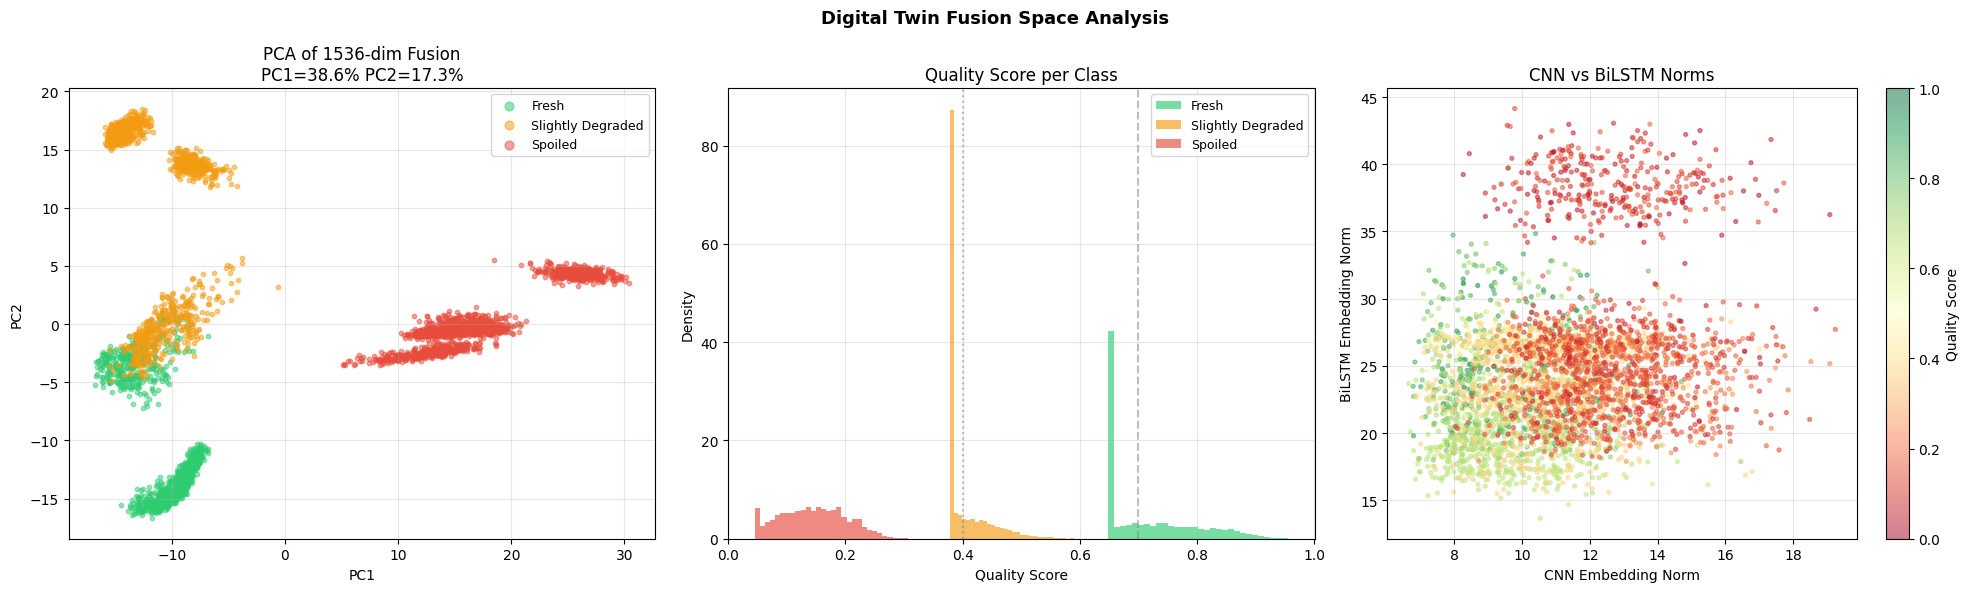

Saved: eda_fusion_space.png


In [5]:
# ================================================================
# CELL 5: EDA — Fusion Vector Space
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Digital Twin Fusion Space Analysis',
             fontsize=13, fontweight='bold')

# PCA of fusion vectors
pca = PCA(n_components=2, random_state=42)
f_pca = pca.fit_transform(fusion_test)
var   = pca.explained_variance_ratio_

for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = TEST_LABELS_T == ci
    axes[0].scatter(f_pca[mask,0], f_pca[mask,1],
                    c=ccol, s=10, alpha=0.5, label=cname)
axes[0].set_title(f'PCA of 1536-dim Fusion\nPC1={var[0]:.1%} PC2={var[1]:.1%}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=9, markerscale=2); axes[0].grid(alpha=0.3)

# Quality score distribution per class
for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = TRAIN_LABELS_T == ci
    axes[1].hist(train_scores[mask], bins=30, alpha=0.65,
                 color=ccol, label=cname, density=True)
axes[1].axvline(0.70, color='gray', ls='--', alpha=0.5)
axes[1].axvline(0.40, color='gray', ls=':',  alpha=0.5)
axes[1].set_xlabel('Quality Score'); axes[1].set_ylabel('Density')
axes[1].set_title('Quality Score per Class')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# CNN vs BiLSTM embedding norms
cnn_norms    = np.linalg.norm(cnn_test,    axis=1)
bilstm_norms = np.linalg.norm(bilstm_test, axis=1)
sc = axes[2].scatter(cnn_norms, bilstm_norms, c=test_scores,
                      cmap='RdYlGn', s=8, alpha=0.5, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[2], label='Quality Score')
axes[2].set_xlabel('CNN Embedding Norm')
axes[2].set_ylabel('BiLSTM Embedding Norm')
axes[2].set_title('CNN vs BiLSTM Norms')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'eda_fusion_space.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_fusion_space.png')

---
## CELL 6 — Build Digital Twin Fusion Model

In [6]:
# ================================================================
# CELL 6: Build Digital Twin Fusion Model
# Two-branch architecture — CNN pathway + BiLSTM pathway
# ================================================================

FUSION_DIM = fusion_train.shape[1]   # 1536

fusion_inp = layers.Input(shape=(FUSION_DIM,), name='fusion_input')

# CNN branch — processes first 1280 dims
cnn_branch = layers.Lambda(lambda x: x[:, :1280],   name='cnn_branch')(fusion_inp)
cnn_branch = layers.Dense(256, activation='relu',    name='cnn_dense')(cnn_branch)
cnn_branch = layers.BatchNormalization()(cnn_branch)
cnn_branch = layers.Dropout(0.3)(cnn_branch)

# BiLSTM branch — processes last 256 dims
bilstm_branch = layers.Lambda(lambda x: x[:, 1280:], name='bilstm_branch')(fusion_inp)
bilstm_branch = layers.Dense(128, activation='relu', name='bilstm_dense')(bilstm_branch)
bilstm_branch = layers.BatchNormalization()(bilstm_branch)
bilstm_branch = layers.Dropout(0.3)(bilstm_branch)

# Merge
merged = layers.Concatenate(name='fusion_merge')([cnn_branch, bilstm_branch])

# Fusion head
x = layers.Dense(512, activation='relu', name='dense1')(merged)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu', name='dense2')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(64,  activation='relu', name='dense3')(x)

# Digital Twin quality score q̂
dt_score = layers.Dense(1, activation='sigmoid',
                         name='digital_twin_score')(x)

fusion_model = models.Model(
    inputs=fusion_inp, outputs=dt_score,
    name='DigitalTwin_Fusion'
)
fusion_model.compile(
    optimizer=optimizers.Adam(1e-3),
    loss='mse',
    metrics=['mae']
)

fusion_model.summary()
print(f'\nInput  : (None, {FUSION_DIM}) = 1280 CNN + 256 BiLSTM')
print(f'Output : (None, 1) = Digital Twin quality score q̂')

Model: "DigitalTwin_Fusion"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fusion_input        │ (None, 1536)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_branch (Lambda) │ (None, 1280)      │          0 │ fusion_input[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_branch       │ (None, 256)       │          0 │ fusion_input[0][… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cnn_dense (Dense)   │ (None, 256)       │    327,936 │ cnn_branch[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bilstm_dense        │ (None, 128)       │     32,896 │ bilstm_branch[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ cnn_dense[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ bilstm_dense[0][… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fusion_merge        │ (None, 384)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 512)       │    197,120 │ fusion_merge[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense2 (Dense)      │ (None, 128)       │     65,664 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense3 (Dense)      │ (None, 64)        │      8,256 │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digital_twin_score  │ (None, 1)         │         65 │ dense3[0][0]      │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 636,033 (2.43 MB)

 Trainable params: 633,985 (2.42 MB)

 Non-trainable params: 2,048 (8.00 KB)


Input  : (None, 1536) = 1280 CNN + 256 BiLSTM
Output : (None, 1) = Digital Twin quality score q̂


---
## CELL 7 — Train

In [7]:
# ================================================================
# CELL 7: Train Fusion Model
# Target RMSE < 0.0954
# Runtime: ~5-10 minutes
# ================================================================

BATCH  = 128
EPOCHS = 50

cbs = [
    callbacks.EarlyStopping(
        monitor='val_mae', mode='min', patience=10,
        restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', mode='min', factor=0.4,
        patience=5, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint(
        '/content/best_fusion.keras',
        monitor='val_mae', mode='min',
        save_best_only=True, verbose=1)
]

print(f'Training: {len(fusion_train):,} | Val: {len(fusion_val):,}')
print(f'Batch={BATCH} | Max epochs={EPOCHS}\n')

history = fusion_model.fit(
    fusion_train, train_scores,
    validation_data=(fusion_val, val_scores),
    epochs=EPOCHS,
    batch_size=BATCH,
    callbacks=cbs
)

fusion_model.load_weights('/content/best_fusion.keras')
best_mae = min(history.history['val_mae'])
print(f'\nBest val MAE : {best_mae:.4f}')
print(f'Paper target : RMSE < 0.0954')

Training: 15,001 | Val: 5,626
Batch=128 | Max epochs=50

Epoch 1/50
115/118 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0336 - mae: 0.1355
Epoch 1: val_mae improved from None to 0.06568, saving model to /content/best_fusion.keras

Epoch 1: finished saving model to /content/best_fusion.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0178 - mae: 0.0995 - val_loss: 0.0068 - val_mae: 0.0657 - learning_rate: 0.0010
Epoch 2/50
116/118 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0074 - mae: 0.0672
Epoch 2: val_mae improved from 0.06568 to 0.04619, saving model to /content/best_fusion.keras

Epoch 2: finished saving model to /content/best_fusion.keras
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0069 - mae: 0.0643 - val_loss: 0.0040 - val_mae: 0.0462 - learning_rate: 0.0010
Epoch 3/50
116/118 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0055 - mae: 0.0574
Epoch 3: val_mae improved from 0.04619 to 0.04539, saving model to /content/best_fusion.keras

Epoch 3: finished saving mode

---
## CELL 8 — Training Curves + Evaluation

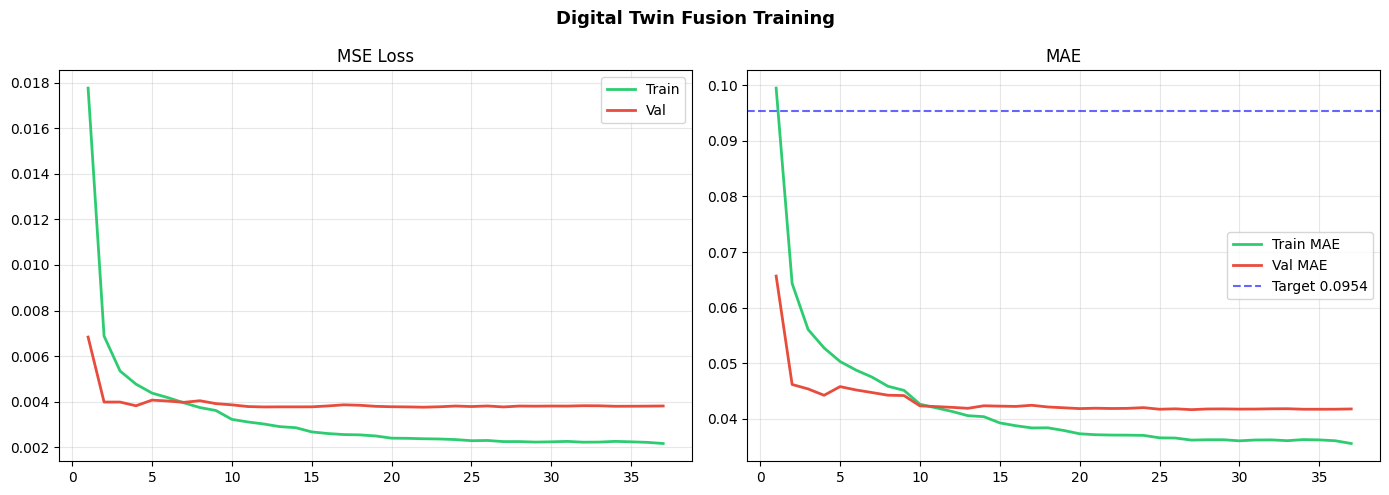


DIGITAL TWIN FUSION — TEST RESULTS
RMSE     : 0.0608  PASS
MAE      : 0.0411
R²       : 0.9379
Accuracy : 61.0%

                   precision    recall  f1-score   support

            Fresh       0.97      0.44      0.60      1164
Slightly Degraded       0.33      0.27      0.29      1164
          Spoiled       0.65      1.00      0.78      1534

         accuracy                           0.61      3862
        macro avg       0.65      0.57      0.56      3862
     weighted avg       0.65      0.61      0.58      3862



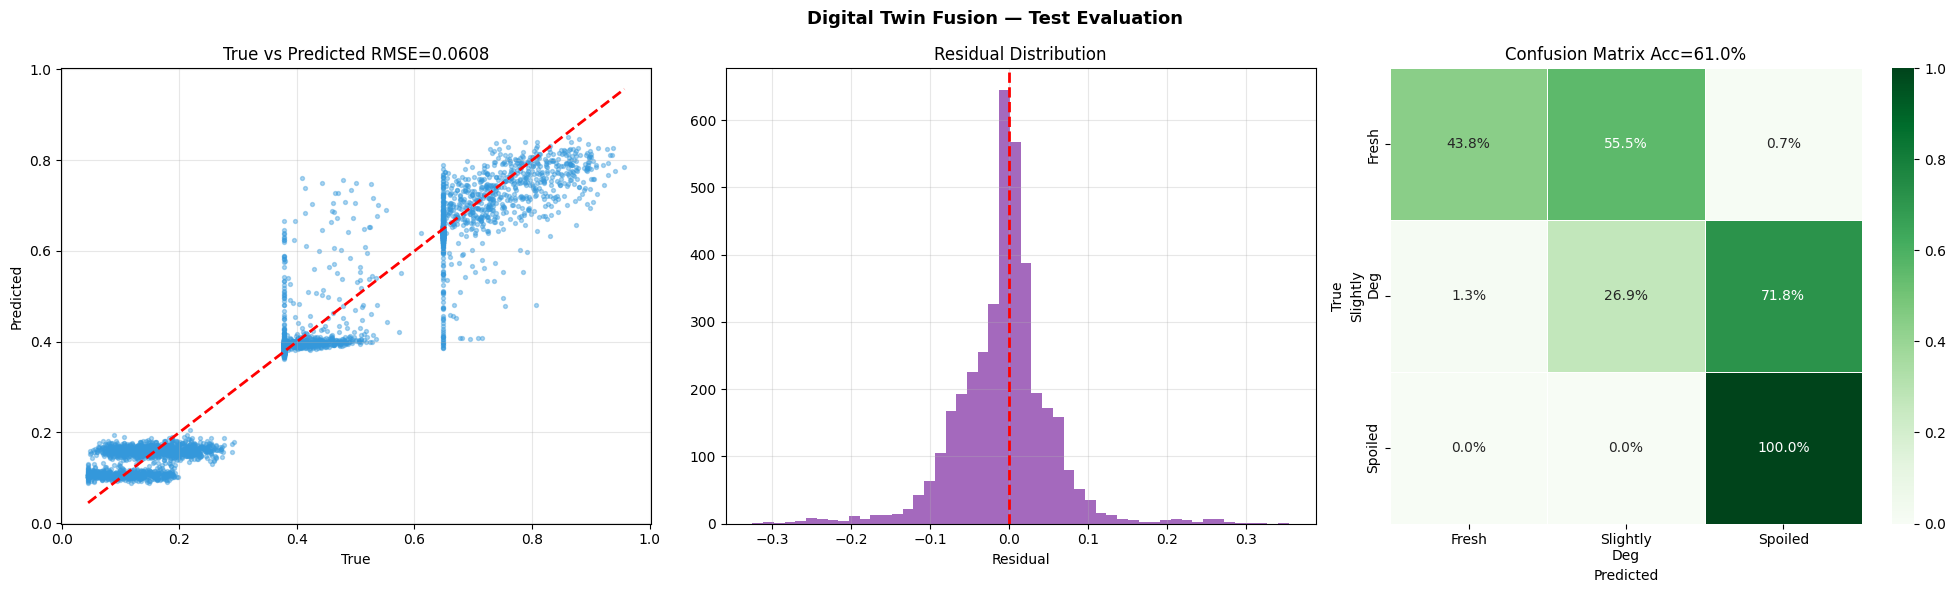

In [8]:
# ================================================================
# CELL 8: Curves + Evaluation
# ================================================================

# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Digital Twin Fusion Training', fontsize=13, fontweight='bold')
eps = range(1, len(history.history['loss'])+1)
axes[0].plot(eps, history.history['loss'],     color='#2ecc71', lw=2, label='Train')
axes[0].plot(eps, history.history['val_loss'], color='#e74c3c', lw=2, label='Val')
axes[0].set_title('MSE Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(eps, history.history['mae'],     color='#2ecc71', lw=2, label='Train MAE')
axes[1].plot(eps, history.history['val_mae'], color='#e74c3c', lw=2, label='Val MAE')
axes[1].axhline(0.0954, color='blue', ls='--', alpha=0.6, label='Target 0.0954')
axes[1].set_title('MAE'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR/'training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Test evaluation
pred_scores = fusion_model.predict(fusion_test, verbose=0).flatten()
rmse = np.sqrt(mean_squared_error(test_scores, pred_scores))
mae  = mean_absolute_error(test_scores, pred_scores)
r2   = r2_score(test_scores, pred_scores)

def score_to_class(s):
    return np.where(s > 0.70, 0, np.where(s > 0.40, 1, 2))

pred_cls = score_to_class(pred_scores)
true_cls = TEST_LABELS_T
acc      = (pred_cls == true_cls).mean()

print('\n' + '='*55)
print('DIGITAL TWIN FUSION — TEST RESULTS')
print('='*55)
print(f'RMSE     : {rmse:.4f}  '
      f'{"PASS" if rmse < 0.0954 else "CLOSE" if rmse < 0.15 else "FAIL"}')
print(f'MAE      : {mae:.4f}')
print(f'R²       : {r2:.4f}')
print(f'Accuracy : {acc:.1%}')
print()
print(classification_report(true_cls, pred_cls, target_names=CLASS_NAMES))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Digital Twin Fusion — Test Evaluation', fontsize=13, fontweight='bold')

axes[0].scatter(test_scores, pred_scores, alpha=0.4, s=8, c='#3498db')
mn, mx = test_scores.min(), test_scores.max()
axes[0].plot([mn,mx],[mn,mx],'r--', lw=2)
axes[0].set_xlabel('True'); axes[0].set_ylabel('Predicted')
axes[0].set_title(f'True vs Predicted RMSE={rmse:.4f}')
axes[0].grid(alpha=0.3)

res = pred_scores - test_scores
axes[1].hist(res, bins=50, color='#8e44ad', alpha=0.8, edgecolor='none')
axes[1].axvline(0, color='red', lw=2, ls='--')
axes[1].set_xlabel('Residual'); axes[1].set_title('Residual Distribution')
axes[1].grid(alpha=0.3)

cm   = confusion_matrix(true_cls, pred_cls)
cm_n = cm.astype('float') / cm.sum(axis=1)[:,np.newaxis]
sns.heatmap(cm_n, annot=True, fmt='.1%', cmap='Greens', ax=axes[2],
            xticklabels=['Fresh','Slightly\nDeg','Spoiled'],
            yticklabels=['Fresh','Slightly\nDeg','Spoiled'], linewidths=0.5)
axes[2].set_title(f'Confusion Matrix Acc={acc:.1%}')
axes[2].set_ylabel('True'); axes[2].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig(OUT_DIR/'evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 9 — Digital Twin State t-SNE

Running t-SNE on 1536-dim fusion vectors...


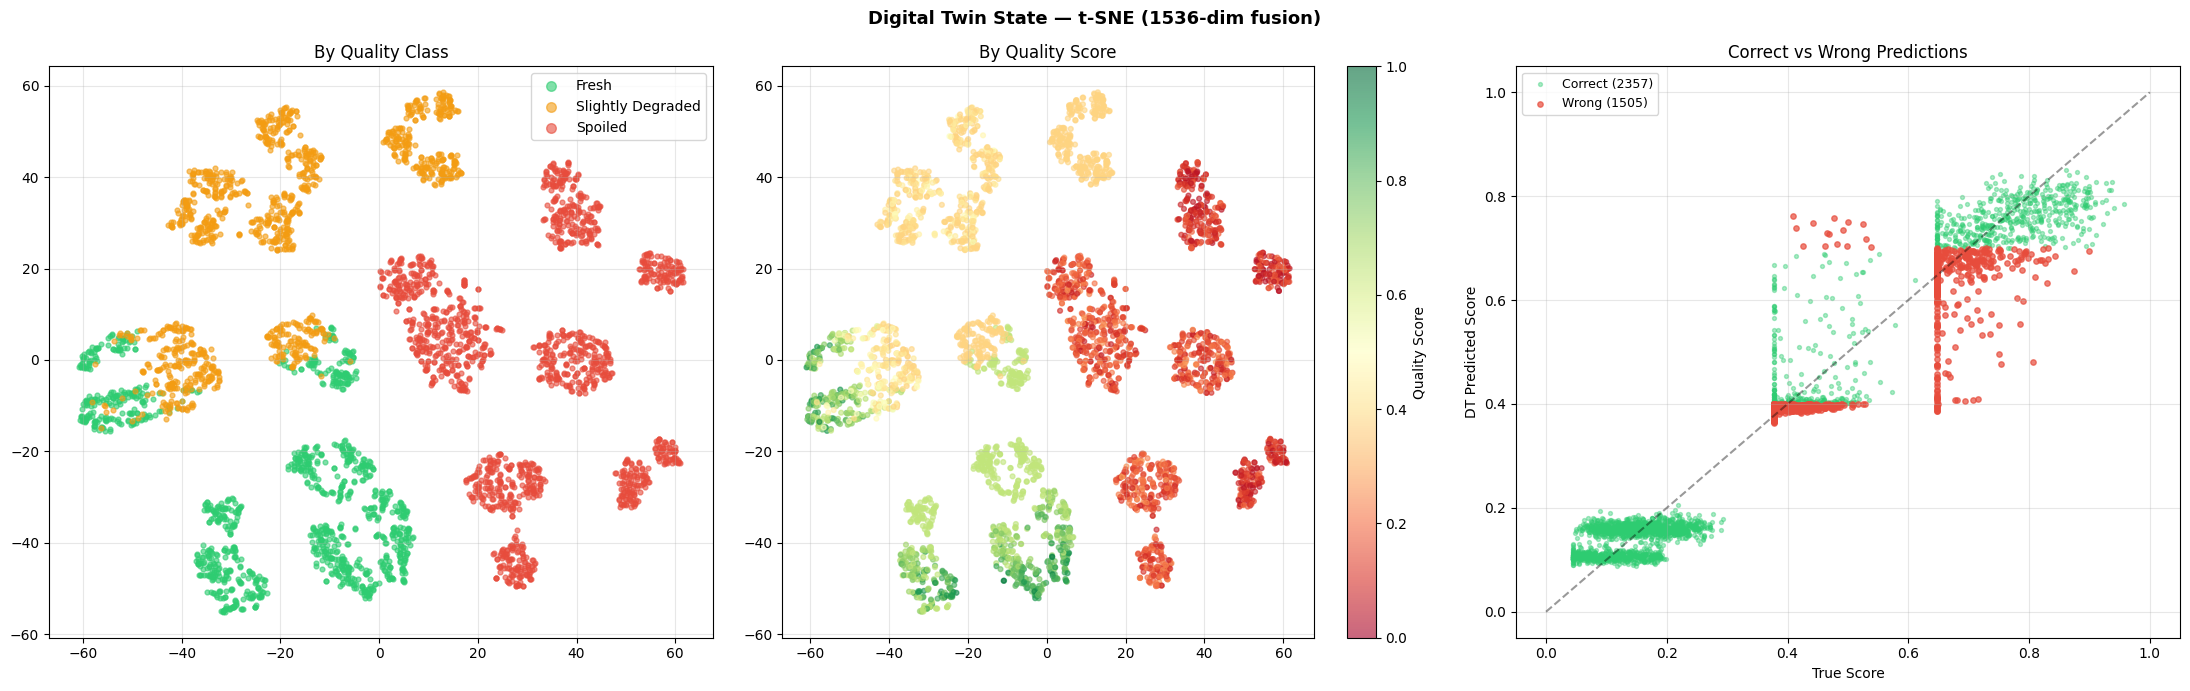

In [9]:
# ================================================================
# CELL 9: t-SNE of Digital Twin State
# ================================================================

print('Running t-SNE on 1536-dim fusion vectors...')
pca50  = PCA(n_components=50, random_state=42)
fus_p  = pca50.fit_transform(fusion_test)
tsne   = TSNE(n_components=2, perplexity=30, n_iter=800, random_state=42)
fus_2d = tsne.fit_transform(fus_p)

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
fig.suptitle('Digital Twin State — t-SNE (1536-dim fusion)',
             fontsize=13, fontweight='bold')

for ci, (cname, ccol) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    mask = TEST_LABELS_T == ci
    axes[0].scatter(fus_2d[mask,0], fus_2d[mask,1],
                    c=ccol, s=12, alpha=0.6, label=cname)
axes[0].set_title('By Quality Class')
axes[0].legend(fontsize=10, markerscale=2)
axes[0].grid(alpha=0.3)

sc = axes[1].scatter(fus_2d[:,0], fus_2d[:,1], c=test_scores,
                      cmap='RdYlGn', s=12, alpha=0.6, vmin=0, vmax=1)
plt.colorbar(sc, ax=axes[1], label='Quality Score')
axes[1].set_title('By Quality Score')
axes[1].grid(alpha=0.3)

correct = pred_cls == true_cls
axes[2].scatter(test_scores[correct],  pred_scores[correct],
                c='#2ecc71', s=8, alpha=0.4, label=f'Correct ({correct.sum()})')
axes[2].scatter(test_scores[~correct], pred_scores[~correct],
                c='#e74c3c', s=15, alpha=0.7, label=f'Wrong ({(~correct).sum()})')
axes[2].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.4)
axes[2].set_xlabel('True Score'); axes[2].set_ylabel('DT Predicted Score')
axes[2].set_title('Correct vs Wrong Predictions')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR/'digital_twin_state.png', dpi=150, bbox_inches='tight')
plt.show()

---
## CELL 10 — Save Digital Twin Vectors for Module 4

In [10]:
# ================================================================
# CELL 10: Save Digital Twin State Vectors → Module 4
# ================================================================

DT_DIR = Path('/content/digital_twin_states')
DT_DIR.mkdir(exist_ok=True)

np.save(DT_DIR/'train_dt_state.npy',    fusion_train)
np.save(DT_DIR/'val_dt_state.npy',      fusion_val)
np.save(DT_DIR/'test_dt_state.npy',     fusion_test)
np.save(DT_DIR/'train_true_scores.npy', train_scores)
np.save(DT_DIR/'val_true_scores.npy',   val_scores)
np.save(DT_DIR/'test_true_scores.npy',  test_scores)
np.save(DT_DIR/'test_pred_scores.npy',  pred_scores)
np.save(DT_DIR/'train_classes.npy',     TRAIN_LABELS_T)
np.save(DT_DIR/'val_classes.npy',       VAL_LABELS_T)
np.save(DT_DIR/'test_classes.npy',      TEST_LABELS_T)
np.save(DT_DIR/'test_pred_classes.npy', pred_cls)

print('Digital Twin state vectors saved:')
for f in sorted(DT_DIR.glob('*.npy')):
    arr = np.load(f)
    print(f'  {f.name:35s} shape={arr.shape}')

print()
print('Agent thresholds for Module 4:')
print('  q̂ > 0.70  → Normal')
print('  0.40–0.70 → Early Warning')
print('  q̂ ≤ 0.40  → Critical Alert')

Digital Twin state vectors saved:
  test_classes.npy                    shape=(3862,)
  test_dt_state.npy                   shape=(3862, 1536)
  test_pred_classes.npy               shape=(3862,)
  test_pred_scores.npy                shape=(3862,)
  test_true_scores.npy                shape=(3862,)
  train_classes.npy                   shape=(15001,)
  train_dt_state.npy                  shape=(15001, 1536)
  train_true_scores.npy               shape=(15001,)
  val_classes.npy                     shape=(5626,)
  val_dt_state.npy                    shape=(5626, 1536)
  val_true_scores.npy                 shape=(5626,)

Agent thresholds for Module 4:
  q̂ > 0.70  → Normal
  0.40–0.70 → Early Warning
  q̂ ≤ 0.40  → Critical Alert


---
## CELL 11 — Save Everything to Google Drive

In [11]:
# ================================================================
# CELL 11: Save to Google Drive
# ================================================================

fusion_model.save('/content/digital_twin_fusion.keras')

FILES = [
    '/content/digital_twin_fusion.keras',
    '/content/best_fusion.keras',
    str(OUT_DIR/'eda_fusion_space.png'),
    str(OUT_DIR/'training_curves.png'),
    str(OUT_DIR/'evaluation.png'),
    str(OUT_DIR/'digital_twin_state.png'),
]

print(f'Saving to: {DRIVE_DIR}')
for f in FILES:
    if os.path.exists(f):
        shutil.copy2(f, DRIVE_DIR/os.path.basename(f))
        print(f'  OK  {os.path.basename(f)}')

dt_dst = DRIVE_DIR/'digital_twin_states'
if dt_dst.exists(): shutil.rmtree(dt_dst)
shutil.copytree(str(DT_DIR), str(dt_dst))
print(f'  OK  digital_twin_states/')

print()
print('=' * 55)
print('MODULE 3 COMPLETE — DIGITAL TWIN FUSION')
print('=' * 55)
print(f'RMSE : {rmse:.4f}  '
      f'{"PASS" if rmse<0.0954 else "CLOSE" if rmse<0.15 else "FAIL"}')
print(f'MAE  : {mae:.4f}')
print(f'R²   : {r2:.4f}')
print(f'Acc  : {acc:.1%}')
print()
print('Architecture summary:')
print(f'  M1 CNN     (1280) + M2 BiLSTM (256) → Fusion (1536) → q̂')
print()
print('Next: Module 4 — Agent Decision Module')

Saving to: /gdrive/MyDrive/FrozenFruitModule3
  OK  digital_twin_fusion.keras
  OK  best_fusion.keras
  OK  eda_fusion_space.png
  OK  training_curves.png
  OK  evaluation.png
  OK  digital_twin_state.png
  OK  digital_twin_states/

MODULE 3 COMPLETE — DIGITAL TWIN FUSION
RMSE : 0.0608  PASS
MAE  : 0.0411
R²   : 0.9379
Acc  : 61.0%

Architecture summary:
  M1 CNN     (1280) + M2 BiLSTM (256) → Fusion (1536) → q̂

Next: Module 4 — Agent Decision Module
